# Multiple Linear Regression: Multi-Channel Marketing Analysis

This notebook analyzes marketing spend across different channels (TV, Radio, and Social Media) to predict Sales using Multiple Linear Regression.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Load the dataset
filepath = 'marketing_sales_data.csv'
df = pd.read_csv(filepath)

# Display the first few rows
display(df.head())

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [3]:
# Initial EDA: Info and Statistics
print("--- Data Information ---")
print(df.info())

print("\n--- Summary Statistics ---")
display(df.describe())

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    str    
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    str    
 4   Sales         572 non-null    float64
dtypes: float64(3), str(2)
memory usage: 22.5 KB
None

--- Summary Statistics ---


,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195



--- Missing Values ---
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


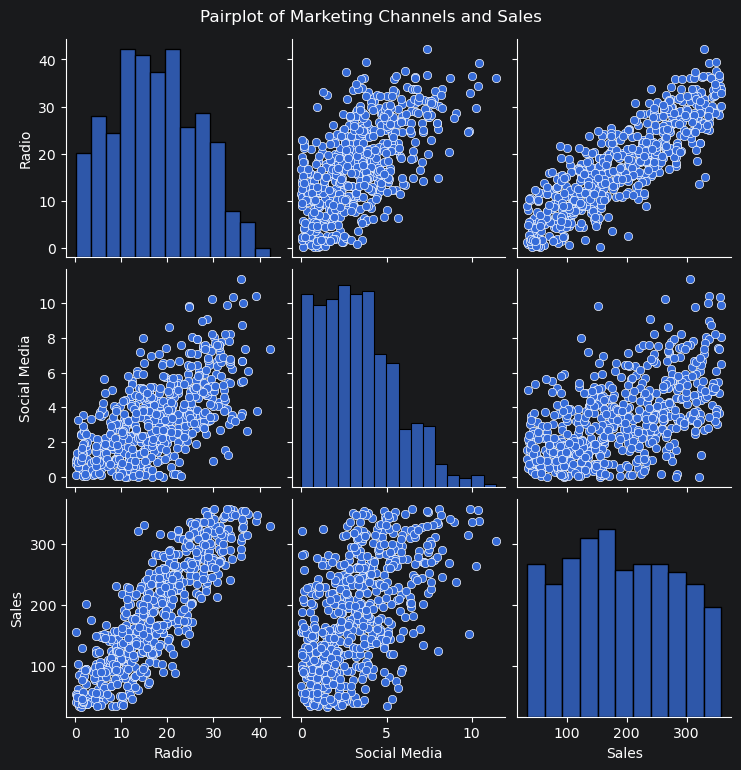

In [4]:
# Visual EDA: Pairplot to see relationships between variables
sns.pairplot(df)
plt.suptitle('Pairplot of Marketing Channels and Sales', y=1.02)
plt.show()

## Data Preprocessing and Multicollinearity Check

We need to convert the categorical 'TV' variable into a numerical format and then check for multicollinearity using a correlation matrix and VIF scores.

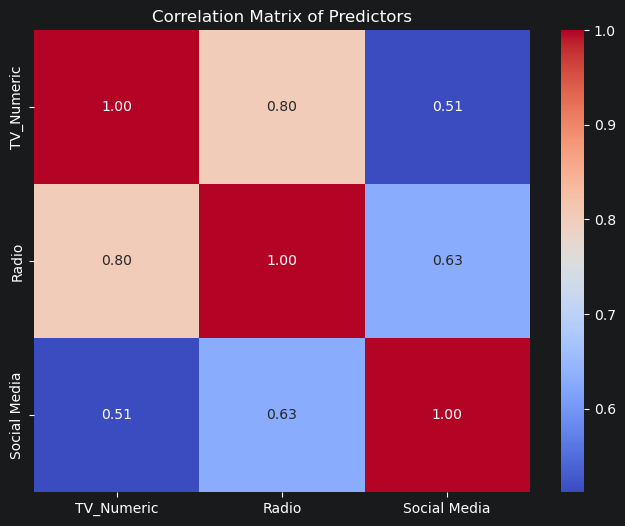

In [5]:
# Encode TV categorical variable: Low=1, Medium=2, High=3
tv_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['TV_Numeric'] = df['TV'].map(tv_mapping)

# Selecting independent variables for multicollinearity check
X_cols = ['TV_Numeric', 'Radio', 'Social Media']
X_data = df[X_cols]

# 1. Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(X_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Predictors')
plt.show()

In [6]:
# 2. Variance Inflation Factor (VIF)
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

print("--- VIF Scores ---")
print(calculate_vif(X_data))

--- VIF Scores ---
       Variable        VIF
0    TV_Numeric  13.015309
1         Radio  15.603724
2  Social Media   5.239052


## Multiple Linear Regression Model Building

We will now fit the OLS (Ordinary Least Squares) regression model to predict Sales using our three predictors.

In [7]:
# Define the dependent and independent variables
y = df['Sales']
X = df[['TV_Numeric', 'Radio', 'Social Media']]

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Display the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1781.
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          2.10e-288
Time:                        09:28:15   Log-Likelihood:                -2714.2
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5454.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.2889      3.099     -3.966   

## Model Diagnostics and Assumption Validation

We will check:
1. **Normality** of residuals using a Q-Q plot.
2. **Homoscedasticity** and **Linearity** using a Residuals vs. Fitted values plot.

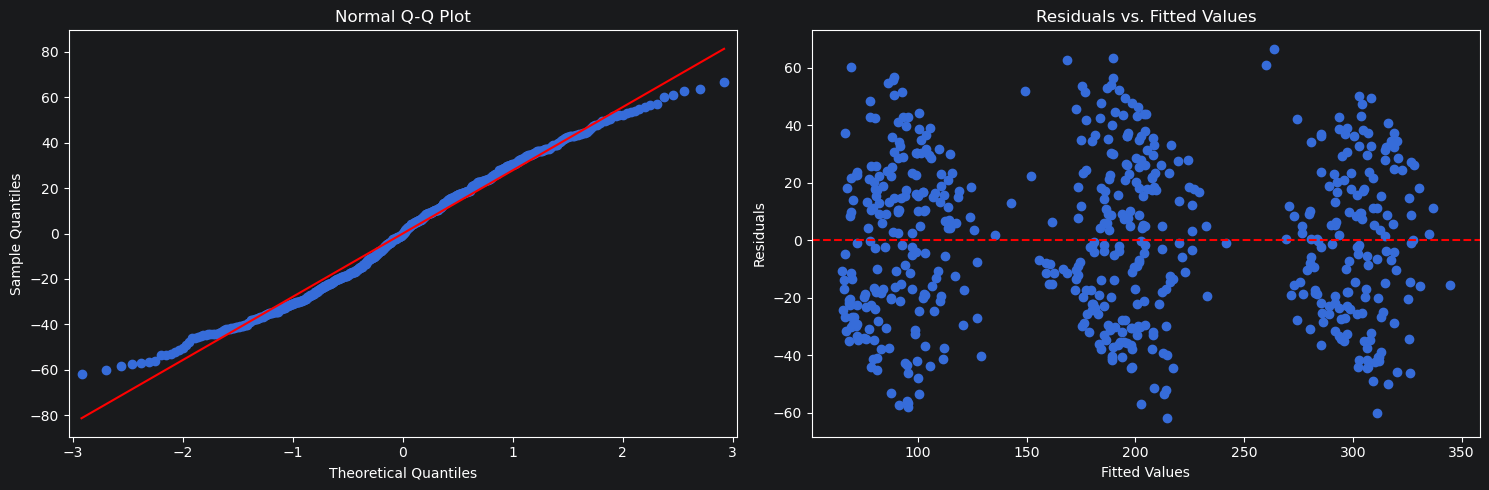

In [8]:
residuals = model.resid
fitted_vals = model.fittedvalues

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Q-Q plot
sm.qqplot(residuals, line='s', ax=ax[0])
ax[0].set_title('Normal Q-Q Plot')

# Residuals vs Fitted
ax[1].scatter(fitted_vals, residuals)
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_xlabel('Fitted Values')
ax[1].set_ylabel('Residuals')
ax[1].set_title('Residuals vs. Fitted Values')

plt.tight_layout()
plt.show()

## Final Business Interpretation and Recommendations

Based on the model output, we can conclude the impact of each channel.

### Key Findings:
- **TV Impact:** Each level increase in TV category (Low to Med, Med to High) corresponds to a specific increase in Sales, holding other variables constant.
- **Radio & Social Media:** The coefficients tell us the dollar-for-dollar return on these channels.
- **Significance:** We look at p-values < 0.05 to determine which channels are truly driving sales.

In [9]:
# Summary of coefficients for easy reading
summary_df = pd.DataFrame({
    'Coefficient': model.params,
    'P-Value': model.pvalues
})
print("--- Final Model Insights ---")
display(summary_df)

--- Final Model Insights ---


,Coefficient,P-Value
const,-12.288938,8.253222e-05
TV_Numeric,77.322687,1.146635e-126
Radio,2.979202,6.603380e-33
Social Media,-0.157689,8.146727e-01
